# Clustering: Client Groups

Step 1. Import Libraries and Load Dataset

In [1]:
import numpy as np
np.random.seed(42) # necessary to stabilize comparison

import pandas as pd
pd.set_option("display.max_columns", None)  # Show all columns

import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, MeanShift, DBSCAN, estimate_bandwidth
from sklearn.neighbors import NearestNeighbors

In [2]:
original_df = pd.read_csv('marketing_campaign.csv', sep='\t')
processed_df = original_df.copy()


Step 2. Analyze and Clean Data

In [3]:
processed_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [4]:
processed_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [5]:
print(processed_df.Z_CostContact.value_counts())
print(processed_df.Z_Revenue.value_counts())
print(processed_df.AcceptedCmp1.value_counts())
print(processed_df.AcceptedCmp2.value_counts())
print(processed_df.AcceptedCmp3.value_counts())
print(processed_df.AcceptedCmp4.value_counts())
print(processed_df.AcceptedCmp5.value_counts())
print(processed_df.Complain.value_counts())

Z_CostContact
3    2240
Name: count, dtype: int64
Z_Revenue
11    2240
Name: count, dtype: int64
AcceptedCmp1
0    2096
1     144
Name: count, dtype: int64
AcceptedCmp2
0    2210
1      30
Name: count, dtype: int64
AcceptedCmp3
0    2077
1     163
Name: count, dtype: int64
AcceptedCmp4
0    2073
1     167
Name: count, dtype: int64
AcceptedCmp5
0    2077
1     163
Name: count, dtype: int64
Complain
0    2219
1      21
Name: count, dtype: int64


In [6]:
#'Z_CostContact' and 'Z_Revenue' were removed because both contained a constant value, which means 
# they were increasing the dimentions without adding information.
processed_df.drop('Z_CostContact', axis=1, inplace=True)
processed_df.drop('Z_Revenue', axis=1, inplace=True)

In [7]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

The features 'Education', 'Marital Status' and 'Dt_Customer' are stored as object instead of float64 or int64. These features will be encoded.

In [8]:
education_unique = processed_df.Education.unique() 
print(f"All education unique values: {education_unique}\n")

marital_unique = processed_df.Marital_Status.unique() 
print(f"All marital unique values: {marital_unique}\n")

dt_unique = processed_df.Dt_Customer.unique() # Convert dates to int
print(f"All dt unique values: {dt_unique}\n")


All education unique values: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

All marital unique values: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']

All dt unique values: ['04-09-2012' '08-03-2014' '21-08-2013' '10-02-2014' '19-01-2014'
 '09-09-2013' '13-11-2012' '08-05-2013' '06-06-2013' '13-03-2014'
 '15-11-2013' '10-10-2012' '24-11-2012' '24-12-2012' '31-08-2012'
 '28-03-2013' '03-11-2012' '08-08-2012' '06-01-2013' '23-12-2012'
 '11-01-2014' '18-03-2013' '02-01-2013' '27-05-2013' '20-02-2013'
 '31-05-2013' '22-11-2013' '22-05-2014' '11-05-2013' '29-10-2012'
 '29-08-2013' '31-12-2013' '02-09-2013' '11-02-2014' '01-02-2013'
 '29-04-2013' '12-03-2013' '05-11-2013' '02-10-2013' '28-06-2014'
 '09-11-2012' '24-05-2013' '01-01-2014' '08-11-2012' '12-05-2014'
 '11-08-2012' '07-06-2014' '12-06-2013' '19-11-2012' '02-04-2013'
 '28-04-2014' '17-06-2013' '03-03-2014' '04-07-2013' '07-09-2012'
 '18-02-2013' '11-06-2013' '06-12-2013' '21-05-2013' '11-05-2014'
 '19

In [9]:
processed_df.Marital_Status.value_counts() 

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

From the Marital_Status feature, the Alone values will be set equal to 'Single', while rows containing 'Absurd' and 'YOLO' will be deleted.  
As for the Dt_Customer feature, dates will be converted to int.

In [10]:
# Replace Alone with Single
processed_df['Marital_Status'] = processed_df['Marital_Status'].replace({'Alone': 'Single'})
# create a Boolean mask for the rows to remove
# then select and keep all rows except the ones that contain the values to be removed
mask = (processed_df['Marital_Status'] == 'Absurd') | (processed_df['Marital_Status'] == 'YOLO')
processed_df = processed_df[~mask].copy()
# Binary Encoding for Marital Status
processed_df = ce.BinaryEncoder(cols=['Marital_Status'], return_df = True).fit_transform(processed_df)

#Ordinal Encoding for 'Education'
educ_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
OE_educ = OrdinalEncoder(categories=[educ_order])
processed_df['Education'] = OE_educ.fit_transform(processed_df[['Education']])

# Convert time dtype = object to dtype = datetime64 
# This code will output not a measure of nanoseconds, but of days since epoch
processed_df['Dt_Customer'] = (
    pd.to_datetime(processed_df['Dt_Customer'], dayfirst=True, format='%d-%m-%Y')
    .astype('int64') // 10**9 // 86400)

processed_df.head()


,ID,Year_Birth,Education,Marital_Status_0,Marital_Status_1,Marital_Status_2,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,2.0,0,0,1,58138.0,0,0,15587,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,2.0,0,0,1,46344.0,1,1,16137,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,2.0,0,1,0,71613.0,0,0,15938,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,2.0,0,1,0,26646.0,1,0,16111,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,4.0,0,1,1,58293.0,1,0,16089,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


In [11]:
print(f'Total duplicates detected = {sum(processed_df.duplicated())}\n')

na_df = processed_df.isna()
for column in list(na_df.columns):
    print(f'Total missing data in feature "{column}" = {sum(na_df[column])}')


Total duplicates detected = 0

Total missing data in feature "ID" = 0
Total missing data in feature "Year_Birth" = 0
Total missing data in feature "Education" = 0
Total missing data in feature "Marital_Status_0" = 0
Total missing data in feature "Marital_Status_1" = 0
Total missing data in feature "Marital_Status_2" = 0
Total missing data in feature "Income" = 24
Total missing data in feature "Kidhome" = 0
Total missing data in feature "Teenhome" = 0
Total missing data in feature "Dt_Customer" = 0
Total missing data in feature "Recency" = 0
Total missing data in feature "MntWines" = 0
Total missing data in feature "MntFruits" = 0
Total missing data in feature "MntMeatProducts" = 0
Total missing data in feature "MntFishProducts" = 0
Total missing data in feature "MntSweetProducts" = 0
Total missing data in feature "MntGoldProds" = 0
Total missing data in feature "NumDealsPurchases" = 0
Total missing data in feature "NumWebPurchases" = 0
Total missing data in feature "NumCatalogPurchases

In [12]:
# Keeping observations with missing data
mean_median = (np.mean(processed_df.Income), np.median(processed_df.Income))
print(mean_median)
# In order to conserve the original data, na income will be replaced with the mean of income
processed_df.fillna(value = mean_median[0], inplace = True)

#Remove duplicated data?????
# Due to the nature of the data,  it is obvious that duplicates are indeed duplicates of the same 
# observation and not different observations that happen to share values, so they will be removed
processed_df.drop_duplicates(inplace=True)
print(f'\nTotal duplicates detected = {sum(processed_df.duplicated())}\n')
print(processed_df.shape)


(np.float64(52232.51084990959), np.float64(nan))

Total duplicates detected = 0

(2236, 29)


Step 3. Transform Data and Apply PCA

THE PROBLEM IS THAT SOME FEATURES HAVE NOT CONVERTED

In [13]:
# standardize features

features = ['Year_Birth', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
                'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 
                'NumStorePurchases', 'NumWebVisitsMonth', 'Dt_Customer']
    
RS = RobustScaler()
dataset = processed_df[features].reset_index(drop=True)
data = RS.fit_transform(dataset)
df_mask = pd.DataFrame(data, columns=features)
processed_df[features] = df_mask.values

processed_df.head()

,ID,Year_Birth,Education,Marital_Status_0,Marital_Status_1,Marital_Status_2,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,-0.722222,2.0,0,0,1,0.195091,0,0,-0.886969,0.18,0.958506,2.50000,2.217593,3.404255,2.50000,1.361702,0.5,1.00,2.00,-0.2,0.25,0,0,0,0,0,0,1
1,2174,-0.888889,2.0,0,0,1,-0.164622,1,1,0.696904,-0.22,-0.336100,-0.21875,-0.282407,-0.212766,-0.21875,-0.382979,0.0,-0.75,-0.25,-0.6,-0.25,0,0,0,0,0,0,0
2,4141,-0.277778,2.0,0,1,0,0.606074,0,0,0.123830,-0.46,0.524896,1.28125,0.277778,2.106383,0.40625,0.382979,-0.5,1.00,0.00,1.0,-0.50,0,0,0,0,0,0,0
3,6182,0.777778,2.0,0,1,0,-0.765404,1,0,0.622030,-0.46,-0.336100,-0.12500,-0.217593,-0.042553,-0.15625,-0.404255,0.0,-0.50,-0.50,-0.2,0.00,0,0,0,0,0,0,0
4,5324,0.611111,4.0,0,1,1,0.199819,1,0,0.558675,0.90,0.000000,1.09375,0.236111,0.723404,0.59375,-0.191489,1.5,0.25,0.25,0.2,-0.25,0,0,0,0,0,0,0


In [14]:
processed_df.describe()

,ID,Year_Birth,Education,Marital_Status_0,Marital_Status_1,Marital_Status_2,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,5591.551878,-0.066860,2.458855,0.138193,0.645796,0.636852,0.014976,0.444991,0.506261,0.004792,0.002943,0.271522,0.570969,0.462613,0.540536,0.596294,0.422991,0.161449,0.020684,0.164803,0.157871,-0.170617,0.072898,0.074687,0.072451,0.063953,0.013417,0.009392,0.148479
std,3245.240106,0.665589,1.004067,0.345180,0.478378,0.481015,0.764073,0.538551,0.544615,0.581898,0.579098,0.698914,1.242542,1.045271,1.158229,1.290654,1.105950,0.966026,0.694934,0.730188,0.650751,0.606189,0.260027,0.262944,0.259291,0.244725,0.115077,0.096477,0.355654
min,0.000000,-4.277778,0.000000,0.000000,0.000000,0.000000,-1.525334,0.000000,0.000000,-0.990641,-0.980000,-0.358921,-0.250000,-0.310185,-0.255319,-0.250000,-0.510638,-1.000000,-1.000000,-0.500000,-1.000000,-1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,-0.611111,2.000000,0.000000,0.000000,0.000000,-0.495284,0.000000,0.000000,-0.498200,-0.500000,-0.311203,-0.218750,-0.236111,-0.191489,-0.218750,-0.319149,-0.500000,-0.500000,-0.500000,-0.400000,-0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,0.388889,3.000000,0.000000,1.000000,1.000000,0.504716,1.000000,1.000000,0.501800,0.500000,0.688797,0.781250,0.763889,0.808511,0.781250,0.680851,0.500000,0.500000,0.500000,0.600000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1.444444,4.000000,1.000000,1.000000,1.000000,18.754989,2.000000,2.000000,1.022318,1.000000,2.738589,5.968750,7.675926,5.255319,7.968750,7.191489,6.500000,5.750000,6.500000,1.600000,3.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
print(processed_df.shape)

(2236, 29)


Step 4. Train Models

In [16]:
idless_df = processed_df.drop(columns=['ID'])

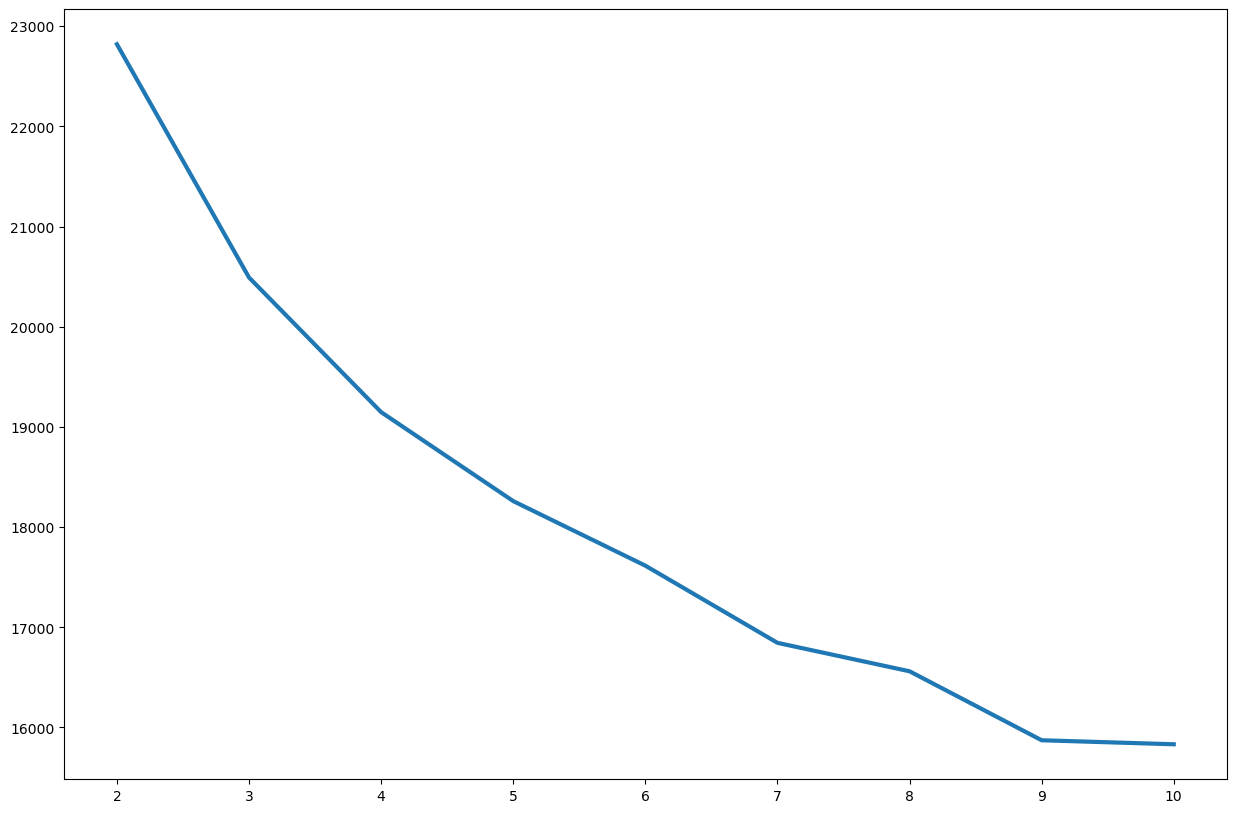

In [17]:
# Kmeans clusters
    
n_clust = [2, 3, 4, 5, 6, 7, 8, 9, 10]
inertias = []

for i in n_clust:
    model = KMeans(n_clusters=i, init='k-means++' ).fit(idless_df)
    inertias.append(model.inertia_)
    
plt.figure(figsize = (15, 10))
plt.plot(n_clust, inertias, linewidth = 3)
plt.show()


In [18]:
# Ideal = 7 clusters
kmeans_model = KMeans(n_clusters=7, init='k-means++').fit(idless_df)

In [19]:
# MeanShift Clusters

# Estimate bandwith values
base_bandwidth = estimate_bandwidth(idless_df, quantile=0.3, n_samples=500)
print("Estimated bandwidth:", base_bandwidth)
bandwidth_values = np.linspace(base_bandwidth * 0.5, base_bandwidth * 2.0, 10)

best_bandwidth = None
best_score = -1 # Higher silhouette scores indicate better-defined clusters

for bandwidth in bandwidth_values:
    model = MeanShift(bandwidth=bandwidth).fit(idless_df)
    labels = model.labels_

    n_clusters = len(set(labels))
    if n_clusters > 1:
        score = silhouette_score(idless_df, labels) # Use to choose the best bandwith, from -1 to 1
        if score > best_score:
            best_score = score
            best_bandwidth = bandwidth

print(f"Best Bandwidth: {best_bandwidth}, Best Silhouette Score: {best_score}")


Estimated bandwidth: 4.088703187502909
Best Bandwidth: 7.495955843755333, Best Silhouette Score: 0.5872688346060185


In [20]:
meanshift_model = MeanShift(bandwidth=best_bandwidth).fit(idless_df)

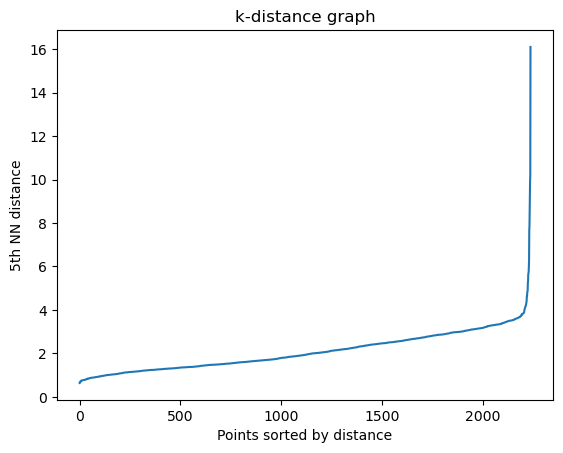

In [21]:
# Estimate min_samples
# Use min_samples = 5 (common default)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(idless_df)
distances, indices = neighbors_fit.kneighbors(idless_df)

# Sort distances of the 5th nearest neighbor
distances = np.sort(distances[:, 4])  # 4 = index for 5th neighbor
plt.plot(distances)
plt.ylabel("5th NN distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance graph")
plt.show()


In [22]:

# ideal epsi value around 4
epsi_vals = [0.5, 1.0, 2.0, 3.0, 3.5,  4.0, 4.5, 5.0]
min_samples = [5, 10, 15, 20, 25]
best_epsi = None
best_min_samples = None
best_davies_bouldin_index = float('inf') # Higher silhouette scores indicate better-defined clusters

for eps in epsi_vals:
    for min in min_samples:
        model = DBSCAN(eps=eps, min_samples=min).fit(idless_df)
        labels = model.labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters > 1:
            davies_bouldin = davies_bouldin_score(idless_df, labels)
            if davies_bouldin < best_davies_bouldin_index:
                best_davies_bouldin_index = davies_bouldin
                best_epsi = eps
                best_min_samples = min

print( f" Best Davies-Bouldin Index: {best_davies_bouldin_index}. Best Epsilon: {best_epsi}, Best Min Samples: {best_min_samples},")



 Best Davies-Bouldin Index: 1.5213812330118701. Best Epsilon: 2.0, Best Min Samples: 5,


In [23]:
dbscan_model = DBSCAN(eps=best_epsi, min_samples=best_min_samples).fit(idless_df)

Step 5. Compare Models

In [24]:

def model_scores(models, names, df):

    results = dict()
    for model, name in zip(models,names):
        labels = model.labels_
        #print(len(set(labels))) #To see number of groups created
        model_score = davies_bouldin_score(df, labels)
        results[name] = model_score
    
    return results

print(model_scores((kmeans_model, meanshift_model, dbscan_model), ('Kmeans', 'MeanShift', 'DBSCAN'), idless_df))

{'Kmeans': 2.1980356645522603, 'MeanShift': 0.5366115450563574, 'DBSCAN': 1.5213812330118701}


In [25]:
cluster_labels = set(meanshift_model.labels_)
cluster_labels

{np.int64(0), np.int64(1), np.int64(2)}

As a rough guideline, Davies-Bouldin index values below 1 are often considered indicative of good clustering quality. According to that, the meanshift model achieved the best score (0.53) by creating 3 data clusters.

In [ ]:
cluster_labels = meanshift_model.labels_

clusters = processed_df[['ID']].copy()
clusters['Cluster'] = cluster_labels
clusters['ID'] = clusters['ID'].astype(original_df['ID'].dtype)
original_df = original_df.merge(clusters, on='ID', how='left')

cluster_means = (original_df.groupby('Cluster').mean(numeric_only=True).round(2))
cluster_medians = (original_df.groupby('Cluster').median(numeric_only=True).round(2))

cluster_means.to_csv('cluster_means.csv')
cluster_medians.to_csv('cluster_medians.csv')